# Merged AgriFieldNet + Morocco XGBoost Crop Classification Training Walkthrough

**Purpose.** This notebook trains a crop classification model that follows the merged AgriFieldNet + Morocco dataset document. The target is restricted to the clean shared crop labels:

- `Corn`
- `Potatoes`
- `Rice`
- `Sugarcane`
- `Wheat`

**Important change from the previous notebook.** This version no longer collapses crops into `corn`, `wheat`, and `other_crop`. It also excludes non-target/land-cover labels such as `Bare Soil`, `Water`, `Weed`, `Fallow`, `Trees`, and `mixte` from the crop-label model.

**Main outputs.** The notebook exports the five artifacts needed for inference:

1. Trained XGBoost model
2. Label encoder
3. Feature column list
4. Lower clipping bounds
5. Upper clipping bounds


## Workflow overview

```mermaid
flowchart LR
    A[Load merged field features] --> B[Validate harmonized schema]
    B --> C[Inspect labels and static Sentinel-2 features]
    C --> D[Keep document-approved crop labels only]
    D --> E[Clean numeric mean features and apply quantile clipping]
    E --> F[Use B01_mean..B12_mean + NDVI_mean as model inputs]
    F --> G[Stratified train/test split]
    G --> H[Train weighted XGBoost classifier]
    H --> I[Evaluate with holdout metrics and cross-validation]
    I --> J[Save model artifacts and reports]
    J --> K[Reload artifacts smoke test]
```

### Reproducibility notes

- `RANDOM_STATE` is fixed for deterministic splitting and model initialization.
- Quantile clipping bounds are computed from the modeling table and saved for inference consistency.
- The target labels follow the document exactly: `Corn`, `Potatoes`, `Rice`, `Sugarcane`, and `Wheat`.
- Metadata columns such as `source_dataset`, `field_id`, `observation_count`, `zone`, and `irrigation` are kept for analysis only and are not used as model inputs.


## 1. Environment setup and paths

This section centralizes imports, constants, file paths, target labels, and plotting defaults. Update `DATA_PATH` only if the merged model-ready dataset is stored somewhere else.


In [2]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

from xgboost import XGBClassifier

RANDOM_STATE = 42
EPS = 1e-6

# Document-aligned merged dataset path.
DATA_PATH = Path("combined_model_ready_scaled.csv")
MODEL_DIR = Path("models")
REPORT_DIR = Path("data/research/merged_crop_classification/outputs/xgboost_training_5_labels")

MODEL_PATH = MODEL_DIR / "xgb_merged_crop_5labels.pkl"
LABEL_ENCODER_PATH = MODEL_DIR / "label_encoder_merged_crop_5labels.pkl"
FEATURE_COLS_PATH = MODEL_DIR / "feature_cols_merged_crop_5labels.pkl"
CLIP_LOWER_PATH = MODEL_DIR / "clip_lower_merged_crop_5labels.pkl"
CLIP_UPPER_PATH = MODEL_DIR / "clip_upper_merged_crop_5labels.pkl"

TARGET_LABELS = ["Corn", "Potatoes", "Rice", "Sugarcane", "Wheat"]
EXCLUDED_SOURCE_LABELS = ["Bare Soil", "Bare soil", "Water", "Weed", "Fallow", "Trees", "mixte"]

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print("Data path:", DATA_PATH)
print("Model directory:", MODEL_DIR.resolve())
print("Report directory:", REPORT_DIR.resolve())
print("Target labels:", TARGET_LABELS)


Data path: combined_model_ready_scaled.csv
Model directory: /content/models
Report directory: /content/data/research/merged_crop_classification/outputs/xgboost_training_5_labels
Target labels: ['Corn', 'Potatoes', 'Rice', 'Sugarcane', 'Wheat']


## 2. Helper functions

These helpers keep the notebook readable and make repeated validation or plotting steps consistent. They do not change the modeling logic.


In [3]:
def require_columns(dataframe: pd.DataFrame, required_columns: list[str], table_name: str = "dataframe") -> None:
    """Raise a clear error if required columns are missing."""
    missing = [col for col in required_columns if col not in dataframe.columns]
    if missing:
        raise ValueError(f"Missing required columns in {table_name}: {missing}")


def plot_count_bar(series: pd.Series, title: str, xlabel: str, ylabel: str = "Count", rotation: int = 45) -> None:
    """Plot a sorted count bar chart from a categorical series or count series."""
    counts = series if isinstance(series, pd.Series) and pd.api.types.is_numeric_dtype(series) else series.value_counts(dropna=False)
    ax = counts.plot(kind="bar", figsize=(10, 5))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotation)
    plt.tight_layout()
    plt.show()


def display_section_summary(title: str, values: dict) -> None:
    """Display compact key-value summaries as a dataframe."""
    summary_df = pd.DataFrame({"metric": values.keys(), "value": values.values()})
    print(title)
    display(summary_df)


## 3. Load merged AgriFieldNet + Morocco dataset

The expected input is the document-aligned merged field-feature table:

`data/research/merged_crop_classification/merged_field_features.csv`

Expected important columns:

- Target label column: `label` preferred, or `target_class` as a fallback for older files.
- Harmonized static Sentinel-2 feature columns:
  - `B01_mean`, `B02_mean`, `B03_mean`, `B04_mean`, `B05_mean`, `B06_mean`, `B07_mean`, `B08_mean`, `B8A_mean`, `B09_mean`, `B11_mean`, `B12_mean`, `NDVI_mean`
- Optional metadata columns for reporting only:
  - `source_dataset`, `field_id`, `observation_count`, `zone`, `irrigation`

If an older dataset still uses raw names like `B02`, `B03`, or `NDVI`, the notebook renames them into the harmonized `_mean` schema before training.


In [4]:
df = pd.read_csv(DATA_PATH)

print("Preview:")
display(df.head())

display_section_summary(
    "Dataset summary",
    {
        "rows": f"{len(df):,}",
        "columns": f"{df.shape[1]:,}",
        "duplicate rows": f"{df.duplicated().sum():,}",
    },
)

print("Column overview:")
display(pd.DataFrame({
    "column": df.columns,
    "dtype": [df[col].dtype for col in df.columns],
    "missing_count": [df[col].isna().sum() for col in df.columns],
    "missing_pct": [df[col].isna().mean() * 100 for col in df.columns],
}).sort_values("missing_pct", ascending=False))


Preview:


,field_id,source,target_class,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B09,B11,B12,NDVI
0,agrifieldnet_001c1_6532,agrifieldnet,Corn,0.172549,0.139562,0.119723,0.093656,0.107036,0.215225,0.287659,0.269435,0.059746,0.155940,0.076125,0.312111,0.483200
1,agrifieldnet_001c1_6640,agrifieldnet,Corn,0.172549,0.141176,0.123529,0.100654,0.117647,0.211111,0.266667,0.252941,0.058824,0.186928,0.097386,0.294118,0.430234
2,agrifieldnet_001c1_6641,agrifieldnet,Corn,0.172549,0.142048,0.124183,0.101089,0.121569,0.210022,0.258824,0.240087,0.058824,0.189107,0.101961,0.282789,0.406709
3,agrifieldnet_001c1_6642,agrifieldnet,Corn,0.172549,0.140523,0.124837,0.101961,0.126797,0.215686,0.260131,0.247712,0.058824,0.196078,0.105882,0.288889,0.416782
4,agrifieldnet_005fe_2077,agrifieldnet,Wheat,0.173308,0.157748,0.153953,0.175079,0.184567,0.214168,0.238963,0.230993,0.054649,0.296901,0.212524,0.264137,0.137582


Dataset summary


,metric,value
0,rows,"11,284"
1,columns,16
2,duplicate rows,0


Column overview:


,column,dtype,missing_count,missing_pct
0,field_id,object,0,0.0
1,source,object,0,0.0
2,target_class,object,0,0.0
3,B01,float64,0,0.0
4,B02,float64,0,0.0
5,B03,float64,0,0.0
6,B04,float64,0,0.0
7,B05,float64,0,0.0
8,B06,float64,0,0.0
9,B07,float64,0,0.0


## 4. Validate required schema

This step fails early if the dataset does not contain the columns required by the baseline workflow.


In [5]:
DOC_FEATURE_COLS = [
    "B01_mean",
    "B02_mean",
    "B03_mean",
    "B04_mean",
    "B05_mean",
    "B06_mean",
    "B07_mean",
    "B08_mean",
    "B8A_mean",
    "B09_mean",
    "B11_mean",
    "B12_mean",
    "NDVI_mean",
]

# Prefer the document target column, but support older notebook inputs.
if "label" in df.columns:
    label_col = "label"
elif "target_class" in df.columns:
    label_col = "target_class"
else:
    raise ValueError("Expected a target column named 'label' or 'target_class'.")

# Normalize older raw band names to the document's harmonized *_mean schema when needed.
raw_to_mean = {
    "B01": "B01_mean", "B1": "B01_mean",
    "B02": "B02_mean", "B2": "B02_mean",
    "B03": "B03_mean", "B3": "B03_mean",
    "B04": "B04_mean", "B4": "B04_mean",
    "B05": "B05_mean", "B5": "B05_mean",
    "B06": "B06_mean", "B6": "B06_mean",
    "B07": "B07_mean", "B7": "B07_mean",
    "B08": "B08_mean", "B8": "B08_mean",
    "B8A": "B8A_mean",
    "B09": "B09_mean", "B9": "B09_mean",
    "B11": "B11_mean",
    "B12": "B12_mean",
    "NDVI": "NDVI_mean",
}

rename_map = {
    raw: mean
    for raw, mean in raw_to_mean.items()
    if raw in df.columns and mean not in df.columns
}
if rename_map:
    df = df.rename(columns=rename_map)
    print("Renamed older raw feature columns into document schema:", rename_map)

if "NDVI_mean" not in df.columns and {"B08_mean", "B04_mean"}.issubset(df.columns):
    df["NDVI_mean"] = (df["B08_mean"] - df["B04_mean"]) / (df["B08_mean"] + df["B04_mean"] + EPS)
    print("NDVI_mean was not found, so it was computed from B08_mean and B04_mean.")
elif "NDVI_mean" in df.columns:
    print("NDVI_mean column found in the dataset.")

require_columns(df, [label_col] + DOC_FEATURE_COLS, table_name="merged crop classification dataset")

common_cols = DOC_FEATURE_COLS
metadata_cols = [col for col in ["source_dataset", "field_id", "observation_count", "zone", "irrigation"] if col in df.columns]

print("Target column:", label_col)
print("Validated model input features:", common_cols)
print("Metadata columns kept for reporting only:", metadata_cols)


Renamed older raw feature columns into document schema: {'B01': 'B01_mean', 'B02': 'B02_mean', 'B03': 'B03_mean', 'B04': 'B04_mean', 'B05': 'B05_mean', 'B06': 'B06_mean', 'B07': 'B07_mean', 'B08': 'B08_mean', 'B8A': 'B8A_mean', 'B09': 'B09_mean', 'B11': 'B11_mean', 'B12': 'B12_mean', 'NDVI': 'NDVI_mean'}
NDVI_mean column found in the dataset.
Target column: target_class
Validated model input features: ['B01_mean', 'B02_mean', 'B03_mean', 'B04_mean', 'B05_mean', 'B06_mean', 'B07_mean', 'B08_mean', 'B8A_mean', 'B09_mean', 'B11_mean', 'B12_mean', 'NDVI_mean']
Metadata columns kept for reporting only: ['field_id']


## 5. Exploratory data analysis

The goal of this section is to confirm class balance, inspect numeric feature scale, and identify obvious data-quality issues before training.


Original label counts:


,target_class,count
0,Wheat,4762
1,Fallow,2649
2,Corn,1556
3,Berseem,873
4,Potatoes,459
5,Beets,424
6,Sugarcane,267
7,Rice,156
8,Tomatoes,128
9,Beans,10


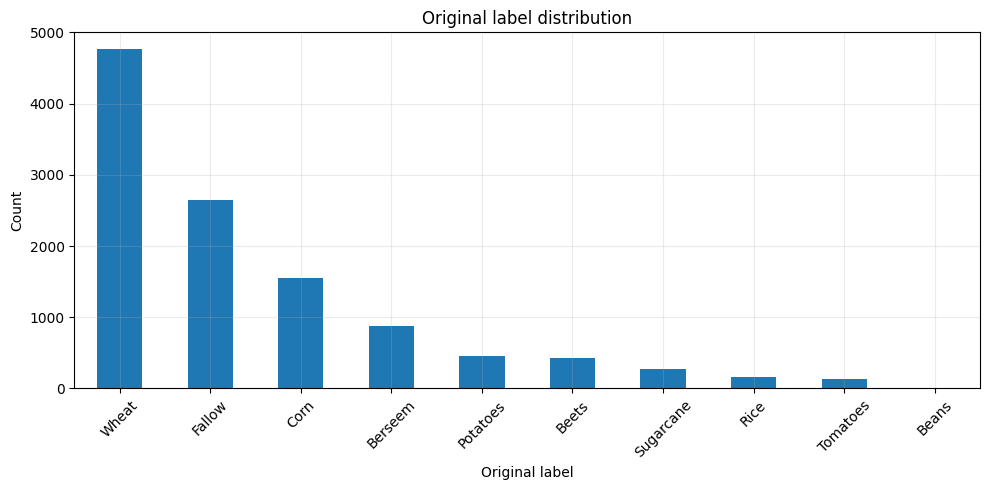

Metadata availability summary:


,count,unique,top,freq
field_id,11284,11284,el haouz_Seasonal Crop_20250130_086,1


In [6]:
label_counts = df[label_col].value_counts(dropna=False)
print("Original label counts:")
display(label_counts.rename_axis(label_col).reset_index(name="count"))

plot_count_bar(
    label_counts,
    title="Original label distribution",
    xlabel="Original label",
    ylabel="Count",
    rotation=45,
)

if metadata_cols:
    print("Metadata availability summary:")
    display(df[metadata_cols].describe(include="all").T)


Raw band and NDVI descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
B01_mean,11284.0,0.102375,0.056928,0.027351,0.052910,0.068498,0.169935,0.196078
B02_mean,11284.0,0.102295,0.044306,0.033802,0.063242,0.083817,0.150980,0.199931
B03_mean,11284.0,0.120242,0.032268,0.054895,0.093277,0.117647,0.145238,0.278568
B04_mean,11284.0,0.143514,0.041969,0.047378,0.113725,0.143397,0.170370,0.377432
B05_mean,11284.0,0.171501,0.038813,0.080805,0.145512,0.170156,0.193052,0.415979
B06_mean,11284.0,0.232417,0.044877,0.093007,0.205430,0.229132,0.257392,0.423311
B07_mean,11284.0,0.264599,0.051555,0.103104,0.236081,0.262526,0.293242,0.467778
B08_mean,11284.0,0.267390,0.056087,0.112352,0.233395,0.258170,0.300461,0.484767
B8A_mean,11284.0,0.196725,0.126785,0.027451,0.054902,0.231337,0.307428,0.484486
B09_mean,11284.0,0.291458,0.059199,0.067679,0.261209,0.299020,0.332253,0.454236


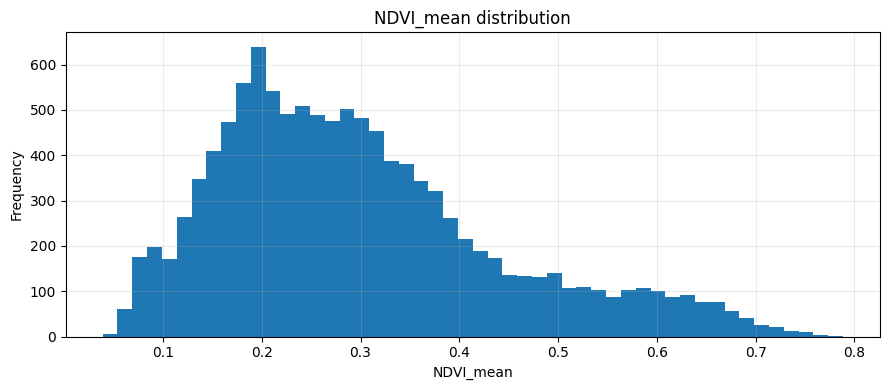

In [8]:
print("Raw band and NDVI descriptive statistics:")
display(df[common_cols].describe().T)

ax = df["NDVI_mean"].hist(bins=50, figsize=(9, 4))
ax.set_title("NDVI_mean distribution")
ax.set_xlabel("NDVI_mean")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [9]:
missing_common = df[common_cols].isna().sum().sort_values(ascending=False)
missing_common_pct = (df[common_cols].isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_common,
    "missing_pct": missing_common_pct,
})

print("Missing values in modeling input features:")
display(missing_summary)

if missing_summary["missing_count"].sum() > 0:
    ax = missing_summary["missing_count"].plot(kind="bar", figsize=(9, 4))
    ax.set_title("Missing values by input feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Missing count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the common input features.")


Missing values in modeling input features:


,missing_count,missing_pct
B01_mean,0,0.0
B02_mean,0,0.0
B03_mean,0,0.0
B04_mean,0,0.0
B05_mean,0,0.0
B06_mean,0,0.0
B07_mean,0,0.0
B08_mean,0,0.0
B8A_mean,0,0.0
B09_mean,0,0.0


No missing values found in the common input features.


## 6. Target cleaning using the document-approved labels

The document says the crop model should keep only clean shared crop labels:

| Retained label |
|---|
| `Corn` |
| `Potatoes` |
| `Rice` |
| `Sugarcane` |
| `Wheat` |

The notebook now excludes everything outside those five labels. This means labels such as `Bare Soil`, `Water`, `Weed`, `Fallow`, `Trees`, `mixte`, `Alfalfa`, `Beets`, `Tomatoes`, and `Beans` are not converted into `other_crop`; they are removed from the training target.


Document-approved labels used for training:


,retained_model_label,status
0,Corn,kept for crop-label model
1,Potatoes,kept for crop-label model
2,Rice,kept for crop-label model
3,Sugarcane,kept for crop-label model
4,Wheat,kept for crop-label model


Target cleaning summary


,metric,value
0,rows before cleaning,"11,284"
1,excluded rows,"4,084"
2,rows after cleaning,"7,200"
3,retained share,63.81%
4,target labels,"Corn, Potatoes, Rice, Sugarcane, Wheat"


Excluded source-label counts:


,target_class,excluded_count
0,Fallow,2649
1,Berseem,873
2,Beets,424
3,Tomatoes,128
4,Beans,10


Final training label counts:


,label,count
0,Corn,1556
1,Potatoes,459
2,Rice,156
3,Sugarcane,267
4,Wheat,4762


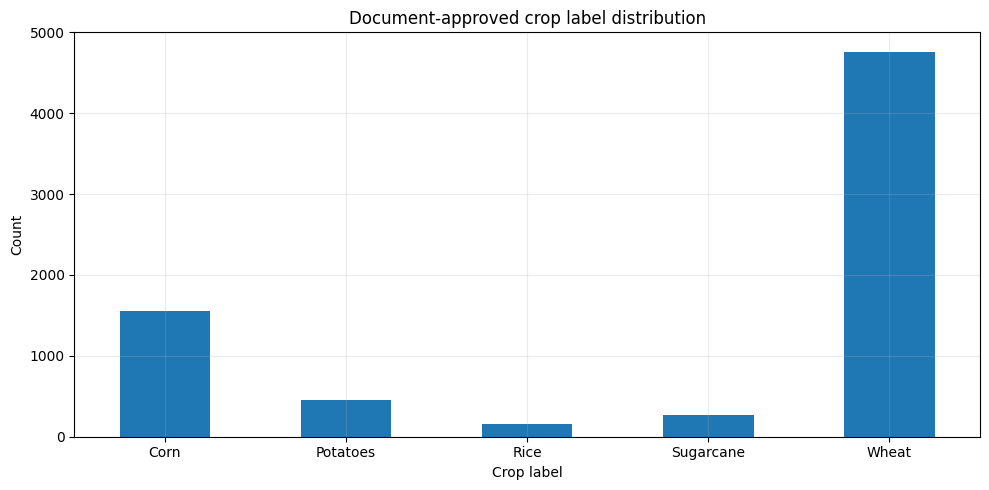

In [10]:
def normalize_label(value):
    """Map source labels to the document-approved label casing, or return NaN if not approved."""
    if pd.isna(value):
        return np.nan
    normalized = str(value).strip().lower().replace("_", " ").replace("-", " ")
    normalized = " ".join(normalized.split())

    approved_lookup = {label.lower(): label for label in TARGET_LABELS}
    return approved_lookup.get(normalized, np.nan)

mapping_df = pd.DataFrame({
    "retained_model_label": TARGET_LABELS,
    "status": "kept for crop-label model",
})
print("Document-approved labels used for training:")
display(mapping_df)

original_label_counts = df[label_col].value_counts(dropna=False)

df_model = df.copy()
df_model["label"] = df_model[label_col].apply(normalize_label)

excluded_rows = df_model["label"].isna().sum()
excluded_label_counts = df_model.loc[df_model["label"].isna(), label_col].value_counts(dropna=False)
df_model = df_model.dropna(subset=["label"]).copy()

display_section_summary(
    "Target cleaning summary",
    {
        "rows before cleaning": f"{len(df):,}",
        "excluded rows": f"{excluded_rows:,}",
        "rows after cleaning": f"{len(df_model):,}",
        "retained share": f"{len(df_model) / len(df):.2%}",
        "target labels": ", ".join(TARGET_LABELS),
    },
)

print("Excluded source-label counts:")
display(excluded_label_counts.rename_axis(label_col).reset_index(name="excluded_count"))

class_counts = df_model["label"].value_counts().reindex(TARGET_LABELS, fill_value=0)
print("Final training label counts:")
display(class_counts.rename_axis("label").reset_index(name="count"))

missing_target_labels = [label for label, count in class_counts.items() if count == 0]
if missing_target_labels:
    raise ValueError(
        "The merged dataset is missing these document-approved labels: "
        f"{missing_target_labels}. Add rows for these labels or remove them intentionally from TARGET_LABELS."
    )

if class_counts.min() < 2:
    raise ValueError(
        "Each retained label needs at least 2 samples for a stratified train/test split. "
        f"Current counts: {class_counts.to_dict()}"
    )

plot_count_bar(
    class_counts,
    title="Document-approved crop label distribution",
    xlabel="Crop label",
    ylabel="Count",
    rotation=0,
)


## 7. Feature preprocessing

The document-aligned preprocessing pipeline is:

1. Convert harmonized static Sentinel-2 mean features to numeric values.
2. Drop rows with missing values in those features.
3. Clip feature values using the 1st and 99th percentiles.
4. Train only on `B01_mean`..`B12_mean` plus `NDVI_mean`.

No metadata columns are used as model inputs, and this version does not add extra engineered indices so the model input matches the document contract exactly.


In [11]:
df_model[common_cols] = df_model[common_cols].apply(pd.to_numeric, errors="coerce")

before_drop = len(df_model)
df_model = df_model.dropna(subset=common_cols).copy()
rows_dropped_for_missing_features = before_drop - len(df_model)

clip_lower = df_model[common_cols].quantile(0.01)
clip_upper = df_model[common_cols].quantile(0.99)

clip_summary = pd.DataFrame({
    "clip_lower_p01": clip_lower,
    "clip_upper_p99": clip_upper,
})

print("Rows dropped because of missing common features:", rows_dropped_for_missing_features)
print("Feature clipping bounds:")
display(clip_summary)

df_model[common_cols] = df_model[common_cols].clip(
    lower=clip_lower,
    upper=clip_upper,
    axis=1,
)


Rows dropped because of missing common features: 0
Feature clipping bounds:


,clip_lower_p01,clip_upper_p99
B01_mean,0.034337,0.185883
B02_mean,0.040919,0.174871
B03_mean,0.064687,0.184314
B04_mean,0.061248,0.229736
B05_mean,0.096251,0.261463
B06_mean,0.127715,0.320053
B07_mean,0.140964,0.368770
B08_mean,0.148800,0.385188
B8A_mean,0.040998,0.391326
B09_mean,0.144372,0.388673


In [12]:
feature_cols = common_cols.copy()

X = df_model[feature_cols].copy()
y = df_model["label"].copy()

print("Final feature count:", len(feature_cols))
print("Feature columns:")
display(pd.DataFrame({"feature": feature_cols}))

print("Feature preview:")
display(X.head())

print("Final feature descriptive statistics:")
display(X.describe().T)


Final feature count: 13
Feature columns:


,feature
0,B01_mean
1,B02_mean
2,B03_mean
3,B04_mean
4,B05_mean
5,B06_mean
6,B07_mean
7,B08_mean
8,B8A_mean
9,B09_mean


Feature preview:


,B01_mean,B02_mean,B03_mean,B04_mean,B05_mean,B06_mean,B07_mean,B08_mean,B8A_mean,B09_mean,B11_mean,B12_mean,NDVI_mean
0,0.172549,0.139562,0.119723,0.093656,0.107036,0.215225,0.287659,0.269435,0.059746,0.155940,0.076125,0.312111,0.483200
1,0.172549,0.141176,0.123529,0.100654,0.117647,0.211111,0.266667,0.252941,0.058824,0.186928,0.097386,0.294118,0.430234
2,0.172549,0.142048,0.124183,0.101089,0.121569,0.210022,0.258824,0.240087,0.058824,0.189107,0.101961,0.282789,0.406709
3,0.172549,0.140523,0.124837,0.101961,0.126797,0.215686,0.260131,0.247712,0.058824,0.196078,0.105882,0.288889,0.416782
4,0.173308,0.157748,0.153953,0.175079,0.184567,0.214168,0.238963,0.230993,0.054649,0.296901,0.212524,0.264137,0.137582


Final feature descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
B01_mean,7200.0,0.102374,0.058239,0.034337,0.053471,0.067178,0.172549,0.185883
B02_mean,7200.0,0.103596,0.045052,0.040919,0.064886,0.083036,0.155505,0.174871
B03_mean,7200.0,0.121774,0.031642,0.064687,0.095354,0.118648,0.150373,0.184314
B04_mean,7200.0,0.147048,0.038137,0.061248,0.119953,0.150686,0.175442,0.229736
B05_mean,7200.0,0.173012,0.035802,0.096251,0.148402,0.176471,0.196931,0.261463
B06_mean,7200.0,0.228392,0.039116,0.127715,0.205420,0.228583,0.252077,0.320053
B07_mean,7200.0,0.259957,0.045723,0.140964,0.235598,0.261123,0.288081,0.368770
B08_mean,7200.0,0.262347,0.049236,0.148800,0.232692,0.256725,0.294094,0.385188
B8A_mean,7200.0,0.194632,0.120266,0.040998,0.058824,0.233323,0.300823,0.391326
B09_mean,7200.0,0.285679,0.055595,0.144372,0.258522,0.293850,0.324749,0.388673


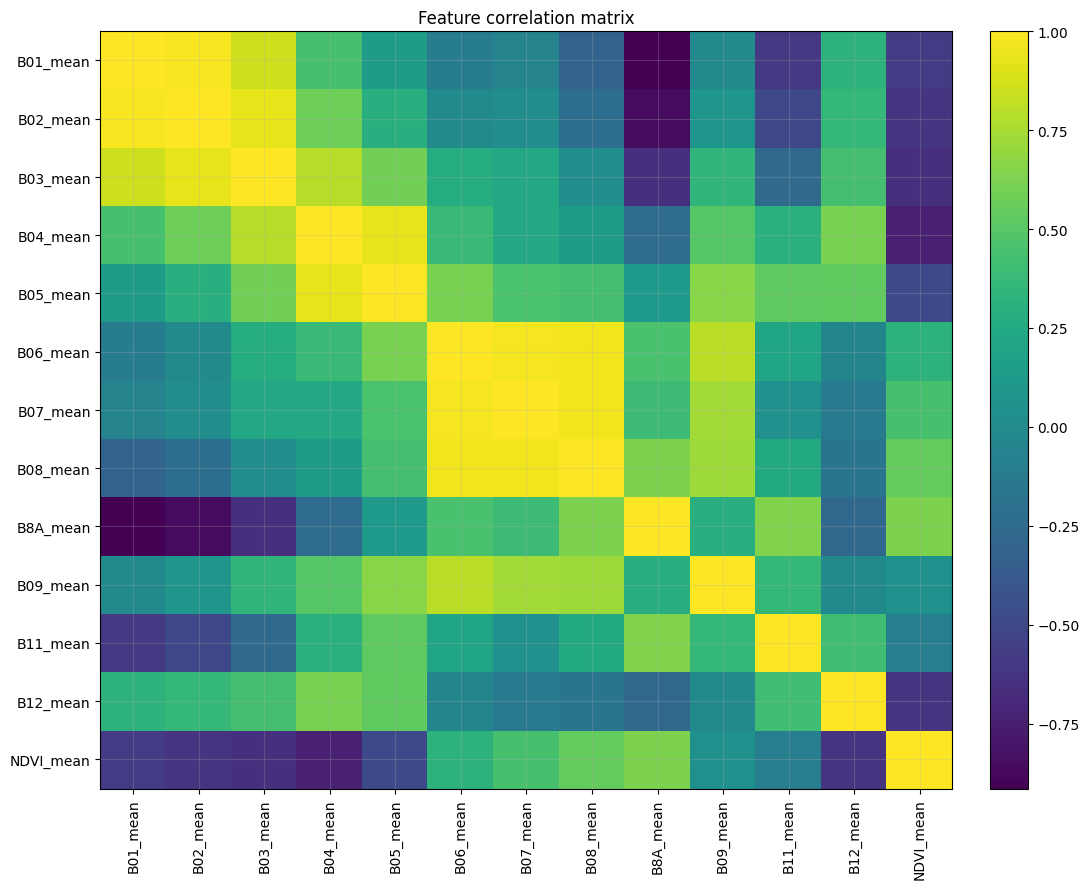

In [13]:
# Optional diagnostic visualization: feature correlation can reveal redundant spectral variables.
corr = X.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, aspect="auto")
ax.set_title("Feature correlation matrix")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 8. Train/test split and class balancing

A stratified split preserves the five crop-label proportions in the holdout set. Balanced sample weights are used during model fitting to reduce the effect of class imbalance.


In [14]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class order used by LabelEncoder:", list(label_encoder.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
)

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train,
)

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(X_train), len(X_test)],
    "features": [X_train.shape[1], X_test.shape[1]],
})

display(split_summary)

train_class_counts = pd.Series(y_train).map(lambda i: label_encoder.classes_[i]).value_counts().rename("train_count")
test_class_counts = pd.Series(y_test).map(lambda i: label_encoder.classes_[i]).value_counts().rename("test_count")
split_class_summary = pd.concat([train_class_counts, test_class_counts], axis=1).fillna(0).astype(int)
print("Class balance by split:")
display(split_class_summary)


Class order used by LabelEncoder: ['Corn', 'Potatoes', 'Rice', 'Sugarcane', 'Wheat']


,split,rows,features
0,train,5760,13
1,test,1440,13


Class balance by split:


,train_count,test_count
Wheat,3810,952
Corn,1245,311
Potatoes,367,92
Sugarcane,213,54
Rice,125,31


## 9. Train XGBoost model

The model is configured for multi-class probabilistic classification over the document-approved labels: `Corn`, `Potatoes`, `Rice`, `Sugarcane`, and `Wheat`.


In [15]:
model = XGBClassifier(
    n_estimators=800,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.75,
    colsample_bytree=0.95,
    min_child_weight=1,
    gamma=0.3,
    reg_lambda=2,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
)

model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
)

print("Model trained successfully.")


Model trained successfully.


## 10. Holdout evaluation

The holdout test set is used for a direct evaluation of the trained model. Macro F1 is especially useful here because it gives each class equal weight.


In [16]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

metrics_df = pd.DataFrame({
    "metric": ["accuracy", "macro_f1", "weighted_f1"],
    "value": [accuracy, macro_f1, weighted_f1],
})

print("Holdout metrics:")
display(metrics_df)

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Holdout metrics:


,metric,value
0,accuracy,0.845139
1,macro_f1,0.753623
2,weighted_f1,0.849403


Classification report:
              precision    recall  f1-score   support

        Corn       0.76      0.86      0.81       311
    Potatoes       0.62      0.73      0.67        92
        Rice       0.84      0.84      0.84        31
   Sugarcane       0.49      0.63      0.55        54
       Wheat       0.93      0.86      0.90       952

    accuracy                           0.85      1440
   macro avg       0.73      0.78      0.75      1440
weighted avg       0.86      0.85      0.85      1440



Confusion matrix values:


,Corn,Potatoes,Rice,Sugarcane,Wheat
Corn,268,7,1,6,29
Potatoes,7,67,1,1,16
Rice,4,0,26,1,0
Sugarcane,6,0,0,34,14
Wheat,66,34,3,27,822


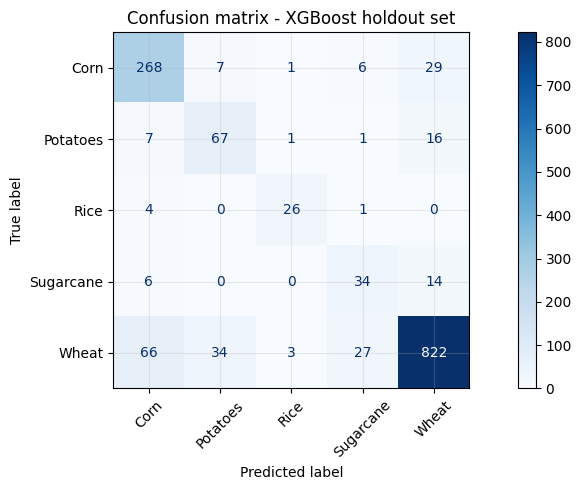

In [17]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_,
)

print("Confusion matrix values:")
display(cm_df)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_,
)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion matrix - XGBoost holdout set")
plt.tight_layout()
plt.show()


## 11. Cross-validation stability check

Stratified cross-validation provides a more stable estimate than a single train/test split. The number of folds is chosen safely from the smallest retained class count, capped at 5.


,fold,macro_f1
0,fold_1,0.758302
1,fold_2,0.756646
2,fold_3,0.790814
3,fold_4,0.761986
4,fold_5,0.780464


Cross-validation summary


,metric,value
0,n_splits,5
1,cv_macro_f1_mean,0.7696
2,cv_macro_f1_std,0.0136
3,cv_macro_f1_min,0.7566
4,cv_macro_f1_max,0.7908


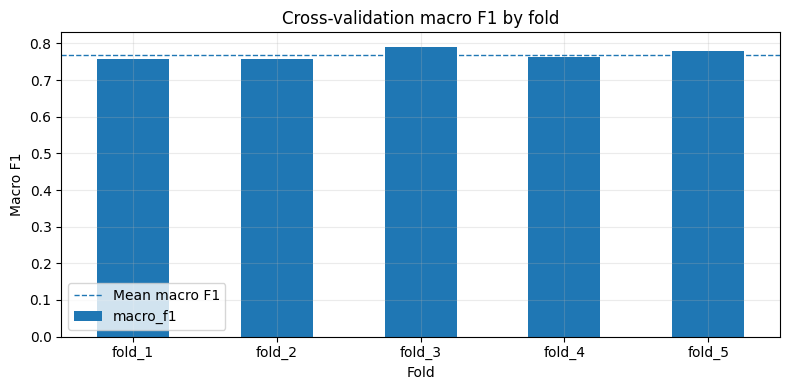

In [18]:
min_class_count = pd.Series(y_encoded).value_counts().min()
n_splits = min(5, int(min_class_count))

if n_splits < 2:
    raise ValueError(
        "Cross-validation requires at least 2 samples in every class. "
        f"Smallest class count is {min_class_count}."
    )

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

cv_model = XGBClassifier(
    n_estimators=800,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.75,
    colsample_bytree=0.95,
    min_child_weight=1,
    gamma=0.3,
    reg_lambda=2,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
)

cv_scores = cross_val_score(
    cv_model,
    X,
    y_encoded,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    "fold": [f"fold_{i}" for i in range(1, len(cv_scores) + 1)],
    "macro_f1": cv_scores,
})

display(cv_summary)

display_section_summary(
    "Cross-validation summary",
    {
        "n_splits": n_splits,
        "cv_macro_f1_mean": f"{cv_scores.mean():.4f}",
        "cv_macro_f1_std": f"{cv_scores.std():.4f}",
        "cv_macro_f1_min": f"{cv_scores.min():.4f}",
        "cv_macro_f1_max": f"{cv_scores.max():.4f}",
    },
)

ax = cv_summary.plot(x="fold", y="macro_f1", kind="bar", legend=False, figsize=(8, 4))
ax.axhline(cv_scores.mean(), linestyle="--", linewidth=1, label="Mean macro F1")
ax.set_title("Cross-validation macro F1 by fold")
ax.set_xlabel("Fold")
ax.set_ylabel("Macro F1")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 12. Feature importance

XGBoost feature importance helps explain which static Sentinel-2 mean features the model used most.

> Important: feature importance is model-specific and can be affected by correlated predictors. It should be treated as an interpretability aid, not causal proof.


In [19]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_,
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False,
).reset_index(drop=True)

feature_importance["rank"] = feature_importance.index + 1
feature_importance = feature_importance[["rank", "feature", "importance"]]

print("Feature importance ranking:")
display(feature_importance)


Feature importance ranking:


,rank,feature,importance
0,1,B11_mean,0.166388
1,2,B05_mean,0.098216
2,3,B02_mean,0.092078
3,4,B8A_mean,0.089996
4,5,B12_mean,0.078303
5,6,NDVI_mean,0.076110
6,7,B06_mean,0.063070
7,8,B01_mean,0.061470
8,9,B03_mean,0.061349
9,10,B09_mean,0.057770


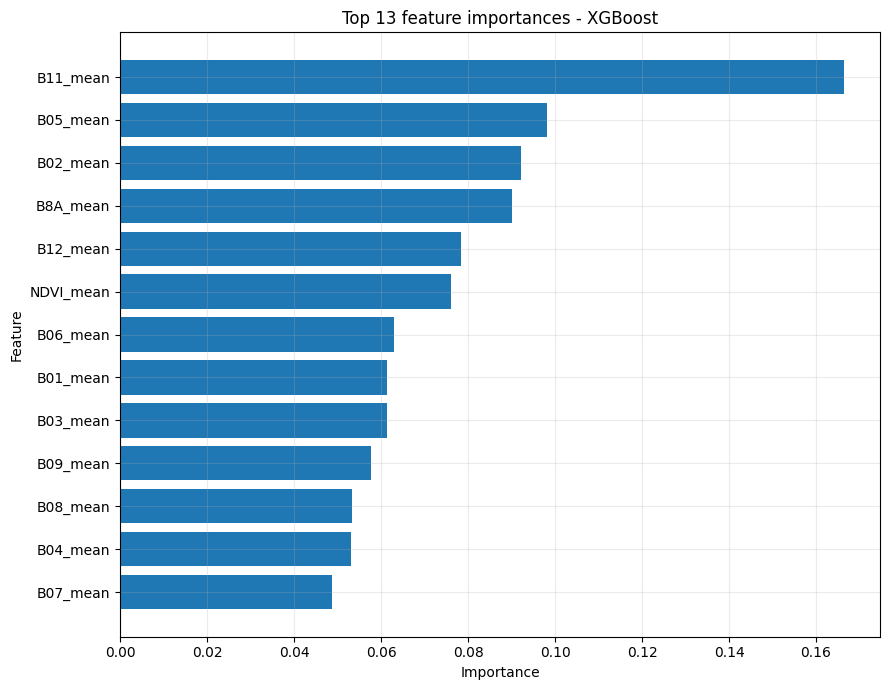

In [20]:
top_n = min(20, len(feature_importance))

top_features = feature_importance.head(top_n).sort_values(
    "importance",
    ascending=True,
)

plt.figure(figsize=(9, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} feature importances - XGBoost")
plt.tight_layout()
plt.show()


## 13. Save model artifacts and reports

The five joblib files below save the document-aligned five-label model, label encoder, feature list, and clipping bounds. Additional CSV and JSON reports are saved for documentation and auditability.


In [21]:
joblib.dump(model, MODEL_PATH)
joblib.dump(label_encoder, LABEL_ENCODER_PATH)
joblib.dump(feature_cols, FEATURE_COLS_PATH)
joblib.dump(clip_lower, CLIP_LOWER_PATH)
joblib.dump(clip_upper, CLIP_UPPER_PATH)

feature_importance.to_csv(REPORT_DIR / "feature_importance.csv", index=False)
cm_df.to_csv(REPORT_DIR / "confusion_matrix.csv")
metrics_df.to_csv(REPORT_DIR / "holdout_metrics.csv", index=False)
cv_summary.to_csv(REPORT_DIR / "cross_validation_scores.csv", index=False)
clip_summary.to_csv(REPORT_DIR / "clip_bounds.csv")

training_report = {
    "accuracy": float(accuracy),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "cv_n_splits": int(n_splits),
    "cv_macro_f1_scores": [float(v) for v in cv_scores],
    "cv_macro_f1_mean": float(cv_scores.mean()),
    "cv_macro_f1_std": float(cv_scores.std()),
    "class_order": list(label_encoder.classes_),
    "target_labels_requested": TARGET_LABELS,
    "feature_count": len(feature_cols),
    "feature_columns": feature_cols,
    "retained_source_labels": TARGET_LABELS,
    "excluded_source_label_counts": {str(k): int(v) for k, v in excluded_label_counts.items()},
    "metadata_columns_not_used_as_features": metadata_cols,
    "rows_after_target_cleaning": int(len(df_model)),
    "rows_dropped_for_missing_features": int(rows_dropped_for_missing_features),
    "model_artifacts": {
        "model": str(MODEL_PATH),
        "label_encoder": str(LABEL_ENCODER_PATH),
        "feature_columns": str(FEATURE_COLS_PATH),
        "clip_lower": str(CLIP_LOWER_PATH),
        "clip_upper": str(CLIP_UPPER_PATH),
    },
    "report_artifacts": {
        "feature_importance": str(REPORT_DIR / "feature_importance.csv"),
        "confusion_matrix": str(REPORT_DIR / "confusion_matrix.csv"),
        "holdout_metrics": str(REPORT_DIR / "holdout_metrics.csv"),
        "cross_validation_scores": str(REPORT_DIR / "cross_validation_scores.csv"),
        "clip_bounds": str(REPORT_DIR / "clip_bounds.csv"),
    },
}

with open(REPORT_DIR / "training_report.json", "w", encoding="utf-8") as f:
    json.dump(training_report, f, indent=2)

print("Saved model artifacts:")
for artifact_path in [MODEL_PATH, LABEL_ENCODER_PATH, FEATURE_COLS_PATH, CLIP_LOWER_PATH, CLIP_UPPER_PATH]:
    print("-", artifact_path)

print("Saved documentation reports to:", REPORT_DIR)


Saved model artifacts:
- models/xgb_merged_crop_5labels.pkl
- models/label_encoder_merged_crop_5labels.pkl
- models/feature_cols_merged_crop_5labels.pkl
- models/clip_lower_merged_crop_5labels.pkl
- models/clip_upper_merged_crop_5labels.pkl
Saved documentation reports to: data/research/merged_crop_classification/outputs/xgboost_training_5_labels


## 14. Reload artifact smoke test

This confirms that the saved files can be reloaded and used for prediction. It is a lightweight check that the training and inference contract is intact.


In [22]:
loaded_model = joblib.load(MODEL_PATH)
loaded_label_encoder = joblib.load(LABEL_ENCODER_PATH)
loaded_feature_cols = joblib.load(FEATURE_COLS_PATH)
loaded_clip_lower = joblib.load(CLIP_LOWER_PATH)
loaded_clip_upper = joblib.load(CLIP_UPPER_PATH)

assert loaded_feature_cols == feature_cols
assert list(loaded_clip_lower.index) == common_cols
assert list(loaded_clip_upper.index) == common_cols

sample_predictions = loaded_model.predict(X_test[loaded_feature_cols].head(5))
sample_labels = loaded_label_encoder.inverse_transform(sample_predictions)

print("Reload test predictions:", sample_labels)
print("Reload check passed.")


Reload test predictions: ['Wheat' 'Sugarcane' 'Corn' 'Wheat' 'Wheat']
Reload check passed.


## 15. Optional AOI-compatible five-label model using only available AOI bands

This section is intentionally separate from the document-aligned 13-feature model above.

Why this exists:

- The validated AOI archive currently exposes only these Sentinel-2 bands: `B02`, `B03`, `B04`, `B05`, `B06`, `B07`, `B08`, `B8A`, and `B11`.
- The document-aligned merged model requires `B01_mean`, `B09_mean`, and `B12_mean`, which are not available in that AOI archive.
- We do **not** impute, invent, or silently fill missing spectral bands.
- Instead, this optional research model trains a separate five-label classifier using only the AOI-compatible shared band features.

This model keeps the same five target labels:

- `Corn`
- `Potatoes`
- `Rice`
- `Sugarcane`
- `Wheat`

It saves separate artifacts so it does not overwrite the original document-aligned model.

In [23]:
# AOI-compatible shared-band feature set.
# These are the bands confirmed available in the AOI cube.zarr test archive.
# This is a deliberate separate model variant, not a replacement for the full document-aligned model.

AOI_SHARED_FEATURE_COLS = [
    "B02_mean",
    "B03_mean",
    "B04_mean",
    "B05_mean",
    "B06_mean",
    "B07_mean",
    "B08_mean",
    "B8A_mean",
    "B11_mean",
]

AOI_MODEL_PATH = MODEL_DIR / "xgb_merged_crop_5labels_aoi_shared_bands.pkl"
AOI_LABEL_ENCODER_PATH = MODEL_DIR / "label_encoder_merged_crop_5labels_aoi_shared_bands.pkl"
AOI_FEATURE_COLS_PATH = MODEL_DIR / "feature_cols_merged_crop_5labels_aoi_shared_bands.pkl"
AOI_CLIP_LOWER_PATH = MODEL_DIR / "clip_lower_merged_crop_5labels_aoi_shared_bands.pkl"
AOI_CLIP_UPPER_PATH = MODEL_DIR / "clip_upper_merged_crop_5labels_aoi_shared_bands.pkl"
AOI_REPORT_DIR = REPORT_DIR.parent / "xgboost_training_5_labels_aoi_shared_bands"
AOI_REPORT_DIR.mkdir(parents=True, exist_ok=True)

require_columns(
    df_model,
    ["label"] + AOI_SHARED_FEATURE_COLS,
    table_name="cleaned five-label merged dataset for AOI-compatible training",
)

missing_from_full_model_for_current_aoi = ["B01_mean", "B09_mean", "B12_mean"]

print("AOI-compatible feature count:", len(AOI_SHARED_FEATURE_COLS))
print("AOI-compatible model features:")
display(pd.DataFrame({"feature": AOI_SHARED_FEATURE_COLS}))
print("Features intentionally excluded from this AOI-compatible variant because the current AOI archive does not provide them:")
display(pd.DataFrame({"excluded_missing_aoi_feature": missing_from_full_model_for_current_aoi}))


AOI-compatible feature count: 9
AOI-compatible model features:


,feature
0,B02_mean
1,B03_mean
2,B04_mean
3,B05_mean
4,B06_mean
5,B07_mean
6,B08_mean
7,B8A_mean
8,B11_mean


Features intentionally excluded from this AOI-compatible variant because the current AOI archive does not provide them:


,excluded_missing_aoi_feature
0,B01_mean
1,B09_mean
2,B12_mean


In [24]:
# Prepare the AOI-compatible training table.
# No feature imputation is performed. Rows missing the AOI-compatible features are dropped explicitly.

df_aoi_model = df_model.copy()
df_aoi_model[AOI_SHARED_FEATURE_COLS] = df_aoi_model[AOI_SHARED_FEATURE_COLS].apply(pd.to_numeric, errors="coerce")

before_aoi_drop = len(df_aoi_model)
df_aoi_model = df_aoi_model.dropna(subset=AOI_SHARED_FEATURE_COLS).copy()
aoi_rows_dropped_for_missing_features = before_aoi_drop - len(df_aoi_model)

aoi_class_counts = df_aoi_model["label"].value_counts().reindex(TARGET_LABELS, fill_value=0)
print("AOI-compatible rows dropped because of missing shared-band features:", aoi_rows_dropped_for_missing_features)
print("AOI-compatible final label counts:")
display(aoi_class_counts.rename_axis("label").reset_index(name="count"))

aoi_missing_target_labels = [label for label, count in aoi_class_counts.items() if count == 0]
if aoi_missing_target_labels:
    raise ValueError(
        "The AOI-compatible training subset is missing these five-label targets after filtering: "
        f"{aoi_missing_target_labels}. Do not train this variant until the dataset contains all labels."
    )

if aoi_class_counts.min() < 2:
    raise ValueError(
        "Each retained label needs at least 2 samples for the AOI-compatible stratified train/test split. "
        f"Current counts: {aoi_class_counts.to_dict()}"
    )

aoi_clip_lower = df_aoi_model[AOI_SHARED_FEATURE_COLS].quantile(0.01)
aoi_clip_upper = df_aoi_model[AOI_SHARED_FEATURE_COLS].quantile(0.99)
aoi_clip_summary = pd.DataFrame({
    "clip_lower_p01": aoi_clip_lower,
    "clip_upper_p99": aoi_clip_upper,
})

print("AOI-compatible clipping bounds:")
display(aoi_clip_summary)

df_aoi_model[AOI_SHARED_FEATURE_COLS] = df_aoi_model[AOI_SHARED_FEATURE_COLS].clip(
    lower=aoi_clip_lower,
    upper=aoi_clip_upper,
    axis=1,
)

X_aoi = df_aoi_model[AOI_SHARED_FEATURE_COLS].copy()
y_aoi = df_aoi_model["label"].copy()

print("AOI-compatible feature preview:")
display(X_aoi.head())


AOI-compatible rows dropped because of missing shared-band features: 0
AOI-compatible final label counts:


,label,count
0,Corn,1556
1,Potatoes,459
2,Rice,156
3,Sugarcane,267
4,Wheat,4762


AOI-compatible clipping bounds:


,clip_lower_p01,clip_upper_p99
B02_mean,0.040919,0.174871
B03_mean,0.064688,0.184314
B04_mean,0.061249,0.229734
B05_mean,0.096251,0.261463
B06_mean,0.127716,0.320048
B07_mean,0.140965,0.368770
B08_mean,0.148802,0.385186
B8A_mean,0.040998,0.391325
B11_mean,0.069020,0.445100


AOI-compatible feature preview:


,B02_mean,B03_mean,B04_mean,B05_mean,B06_mean,B07_mean,B08_mean,B8A_mean,B11_mean
0,0.139562,0.119723,0.093656,0.107036,0.215225,0.287659,0.269435,0.059746,0.076125
1,0.141176,0.123529,0.100654,0.117647,0.211111,0.266667,0.252941,0.058824,0.097386
2,0.142048,0.124183,0.101089,0.121569,0.210022,0.258824,0.240087,0.058824,0.101961
3,0.140523,0.124837,0.101961,0.126797,0.215686,0.260131,0.247712,0.058824,0.105882
4,0.157748,0.153953,0.175079,0.184567,0.214168,0.238963,0.230993,0.054649,0.212524


In [25]:
# Train the separate AOI-compatible five-label model.
# This uses the same target labels, but a reduced AOI-compatible feature contract.

aoi_label_encoder = LabelEncoder()
y_aoi_encoded = aoi_label_encoder.fit_transform(y_aoi)

print("AOI-compatible class order:", list(aoi_label_encoder.classes_))

X_aoi_train, X_aoi_test, y_aoi_train, y_aoi_test = train_test_split(
    X_aoi,
    y_aoi_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_aoi_encoded,
)

aoi_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_aoi_train,
)

aoi_model = XGBClassifier(
    n_estimators=800,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.75,
    colsample_bytree=0.95,
    min_child_weight=1,
    gamma=0.3,
    reg_lambda=2,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
)

aoi_model.fit(
    X_aoi_train,
    y_aoi_train,
    sample_weight=aoi_sample_weights,
)

print("AOI-compatible five-label model trained successfully.")


AOI-compatible class order: ['Corn', 'Potatoes', 'Rice', 'Sugarcane', 'Wheat']
AOI-compatible five-label model trained successfully.


In [26]:
# Evaluate the AOI-compatible model on its holdout split.

aoi_y_pred = aoi_model.predict(X_aoi_test)
aoi_accuracy = accuracy_score(y_aoi_test, aoi_y_pred)
aoi_macro_f1 = f1_score(y_aoi_test, aoi_y_pred, average="macro")
aoi_weighted_f1 = f1_score(y_aoi_test, aoi_y_pred, average="weighted")

aoi_report = classification_report(
    y_aoi_test,
    aoi_y_pred,
    target_names=aoi_label_encoder.classes_,
    output_dict=True,
    zero_division=0,
)
aoi_metrics_df = pd.DataFrame(aoi_report).T.reset_index().rename(columns={"index": "label"})

print("AOI-compatible holdout accuracy:", aoi_accuracy)
print("AOI-compatible holdout macro F1:", aoi_macro_f1)
print("AOI-compatible holdout weighted F1:", aoi_weighted_f1)
display(aoi_metrics_df)

aoi_cm = confusion_matrix(y_aoi_test, aoi_y_pred)
aoi_cm_df = pd.DataFrame(
    aoi_cm,
    index=aoi_label_encoder.classes_,
    columns=aoi_label_encoder.classes_,
)
print("AOI-compatible confusion matrix:")
display(aoi_cm_df)

aoi_feature_importance = pd.DataFrame({
    "feature": AOI_SHARED_FEATURE_COLS,
    "importance": aoi_model.feature_importances_,
}).sort_values("importance", ascending=False)

print("AOI-compatible feature importance:")
display(aoi_feature_importance)


AOI-compatible holdout accuracy: 0.8354166666666667
AOI-compatible holdout macro F1: 0.7305025296798493
AOI-compatible holdout weighted F1: 0.8409700758719112


,label,precision,recall,f1-score,support
0,Corn,0.766764,0.845659,0.804281,311.000000
1,Potatoes,0.644231,0.728261,0.683673,92.000000
2,Rice,0.727273,0.774194,0.750000,31.000000
3,Sugarcane,0.433735,0.666667,0.525547,54.000000
4,Wheat,0.927024,0.853992,0.889010,952.000000
5,accuracy,0.835417,0.835417,0.835417,0.835417
6,macro avg,0.699805,0.773754,0.730503,1440.000000
7,weighted avg,0.851546,0.835417,0.840970,1440.000000


AOI-compatible confusion matrix:


,Corn,Potatoes,Rice,Sugarcane,Wheat
Corn,263,5,2,6,35
Potatoes,3,67,3,2,17
Rice,6,0,24,1,0
Sugarcane,6,0,0,36,12
Wheat,65,32,4,38,813


AOI-compatible feature importance:


,feature,importance
8,B11_mean,0.191510
0,B02_mean,0.133071
3,B05_mean,0.132150
7,B8A_mean,0.123373
2,B04_mean,0.092584
1,B03_mean,0.086074
5,B07_mean,0.085555
4,B06_mean,0.080909
6,B08_mean,0.074774


In [27]:
# Save separate AOI-compatible model artifacts and metadata.
# These filenames are intentionally distinct from the full 13-feature model artifacts.

joblib.dump(aoi_model, AOI_MODEL_PATH)
joblib.dump(aoi_label_encoder, AOI_LABEL_ENCODER_PATH)
joblib.dump(AOI_SHARED_FEATURE_COLS, AOI_FEATURE_COLS_PATH)
joblib.dump(aoi_clip_lower, AOI_CLIP_LOWER_PATH)
joblib.dump(aoi_clip_upper, AOI_CLIP_UPPER_PATH)

aoi_feature_importance.to_csv(AOI_REPORT_DIR / "feature_importance.csv", index=False)
aoi_cm_df.to_csv(AOI_REPORT_DIR / "confusion_matrix.csv")
aoi_metrics_df.to_csv(AOI_REPORT_DIR / "holdout_metrics.csv", index=False)
aoi_clip_summary.to_csv(AOI_REPORT_DIR / "clip_bounds.csv")

aoi_training_report = {
    "model_variant": "merged_crop_5labels_aoi_shared_bands",
    "purpose": "Five-label merged-data model compatible with the currently available AOI archive bands.",
    "known_aoi_available_bands": ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11"],
    "excluded_full_model_features_due_to_current_aoi_missing_bands": missing_from_full_model_for_current_aoi,
    "no_imputation_or_synthetic_bands_used": True,
    "accuracy": float(aoi_accuracy),
    "macro_f1": float(aoi_macro_f1),
    "weighted_f1": float(aoi_weighted_f1),
    "class_order": list(aoi_label_encoder.classes_),
    "target_labels_requested": TARGET_LABELS,
    "feature_count": len(AOI_SHARED_FEATURE_COLS),
    "feature_columns": AOI_SHARED_FEATURE_COLS,
    "rows_after_target_cleaning_and_shared_feature_filtering": int(len(df_aoi_model)),
    "rows_dropped_for_missing_shared_features": int(aoi_rows_dropped_for_missing_features),
    "metadata_columns_not_used_as_features": metadata_cols,
    "model_artifacts": {
        "model": str(AOI_MODEL_PATH),
        "label_encoder": str(AOI_LABEL_ENCODER_PATH),
        "feature_columns": str(AOI_FEATURE_COLS_PATH),
        "clip_lower": str(AOI_CLIP_LOWER_PATH),
        "clip_upper": str(AOI_CLIP_UPPER_PATH),
    },
    "report_artifacts": {
        "feature_importance": str(AOI_REPORT_DIR / "feature_importance.csv"),
        "confusion_matrix": str(AOI_REPORT_DIR / "confusion_matrix.csv"),
        "holdout_metrics": str(AOI_REPORT_DIR / "holdout_metrics.csv"),
        "clip_bounds": str(AOI_REPORT_DIR / "clip_bounds.csv"),
    },
}

with open(AOI_REPORT_DIR / "training_report.json", "w", encoding="utf-8") as f:
    json.dump(aoi_training_report, f, indent=2)

print("Saved AOI-compatible model artifacts:")
for artifact_path in [AOI_MODEL_PATH, AOI_LABEL_ENCODER_PATH, AOI_FEATURE_COLS_PATH, AOI_CLIP_LOWER_PATH, AOI_CLIP_UPPER_PATH]:
    print("-", artifact_path)

print("Saved AOI-compatible reports to:", AOI_REPORT_DIR)


Saved AOI-compatible model artifacts:
- models/xgb_merged_crop_5labels_aoi_shared_bands.pkl
- models/label_encoder_merged_crop_5labels_aoi_shared_bands.pkl
- models/feature_cols_merged_crop_5labels_aoi_shared_bands.pkl
- models/clip_lower_merged_crop_5labels_aoi_shared_bands.pkl
- models/clip_upper_merged_crop_5labels_aoi_shared_bands.pkl
Saved AOI-compatible reports to: data/research/merged_crop_classification/outputs/xgboost_training_5_labels_aoi_shared_bands


In [28]:
# Reload smoke test for the AOI-compatible model.

loaded_aoi_model = joblib.load(AOI_MODEL_PATH)
loaded_aoi_label_encoder = joblib.load(AOI_LABEL_ENCODER_PATH)
loaded_aoi_feature_cols = joblib.load(AOI_FEATURE_COLS_PATH)
loaded_aoi_clip_lower = joblib.load(AOI_CLIP_LOWER_PATH)
loaded_aoi_clip_upper = joblib.load(AOI_CLIP_UPPER_PATH)

assert loaded_aoi_feature_cols == AOI_SHARED_FEATURE_COLS
assert list(loaded_aoi_clip_lower.index) == AOI_SHARED_FEATURE_COLS
assert list(loaded_aoi_clip_upper.index) == AOI_SHARED_FEATURE_COLS

sample_aoi_predictions = loaded_aoi_model.predict(X_aoi_test[loaded_aoi_feature_cols].head(5))
sample_aoi_labels = loaded_aoi_label_encoder.inverse_transform(sample_aoi_predictions)

print("AOI-compatible reload test predictions:", sample_aoi_labels)
print("AOI-compatible reload check passed.")


AOI-compatible reload test predictions: ['Wheat' 'Sugarcane' 'Corn' 'Wheat' 'Potatoes']
AOI-compatible reload check passed.


## 15. Documentation summary

### What this notebook does

- Trains an XGBoost crop classifier on the merged AgriFieldNet + Morocco field-feature dataset.
- Keeps only the document-approved crop labels: `Corn`, `Potatoes`, `Rice`, `Sugarcane`, and `Wheat`.
- Excludes non-target labels and non-shared crops instead of merging them into `other_crop`.
- Uses only the harmonized static Sentinel-2 mean features: `B01_mean`..`B12_mean` plus `NDVI_mean`.
- Keeps metadata columns such as `source_dataset`, `field_id`, `observation_count`, `zone`, and `irrigation` for analysis/reporting only, not for model input.
- Saves model artifacts and audit reports for the five-label research model.
- Adds a separate optional AOI-compatible five-label model variant that uses only the bands available in the current AOI archive: `B02`, `B03`, `B04`, `B05`, `B06`, `B07`, `B08`, `B8A`, and `B11`.
- The AOI-compatible variant does not impute or invent missing `B01`, `B09`, or `B12` values; it trains a separate reduced-feature model with separate artifacts.

### Inference contract for the full document-aligned model

The inference pipeline for the full model must use the same:

- Feature column order from `feature_cols_merged_crop_5labels.pkl`
- Label encoder from `label_encoder_merged_crop_5labels.pkl`
- Quantile clipping bounds from `clip_lower_merged_crop_5labels.pkl` and `clip_upper_merged_crop_5labels.pkl`
- Static mean feature schema: `B01_mean`, `B02_mean`, `B03_mean`, `B04_mean`, `B05_mean`, `B06_mean`, `B07_mean`, `B08_mean`, `B8A_mean`, `B09_mean`, `B11_mean`, `B12_mean`, `NDVI_mean`

### Research note

This notebook is research-only and should be run after validating that the merged dataset contains enough examples for all five crop labels in both source datasets where possible.


### Inference contract for the optional AOI-compatible model

Use these separate artifacts only when the inference AOI has the reduced shared-band schema:

- `models/xgb_merged_crop_5labels_aoi_shared_bands.pkl`
- `models/label_encoder_merged_crop_5labels_aoi_shared_bands.pkl`
- `models/feature_cols_merged_crop_5labels_aoi_shared_bands.pkl`
- `models/clip_lower_merged_crop_5labels_aoi_shared_bands.pkl`
- `models/clip_upper_merged_crop_5labels_aoi_shared_bands.pkl`

The AOI-compatible feature contract is:

- `B02_mean`
- `B03_mean`
- `B04_mean`
- `B05_mean`
- `B06_mean`
- `B07_mean`
- `B08_mean`
- `B8A_mean`
- `B11_mean`

This variant is research-only and should be documented separately from the full 13-feature five-label model.
